In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from scipy.stats import expon
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
from copulas.multivariate import GaussianMultivariate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
import numpy as np
import umap

/home/chucho/Projects/Realistic_TCMS_simulation/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### column differentiation:

In [3]:
#nomi delle colonne da generare
columns_to_generate = [
    'Durata','CabEnabled_M1', 'CabEnabled_M8', 'ERTMS_PiastraSts', 'HMI_ACPntSts_T2', 'HMI_ACPntSts_T7', 'HMI_DCPntSts_T2',
    'HMI_DCPntSts_T7', 'HMI_Iline', 'HMI_Irsts_T2', 'HMI_Irsts_T7', 'HMI_VBatt_T2', 'HMI_VBatt_T4', 'HMI_VBatt_T5',
    'HMI_VBatt_T7', 'HMI_Vline', 'HMI_impSIL', 'LineVoltType', 'MDS_LedLimVel', 'MDS_StatoMarcia', '_GPS_LAT',
    '_GPS_LON', 'ldvvelimps', 'ldvveltreno', 'usB1BCilPres_M1', 'usB1BCilPres_M3', 'usB1BCilPres_M6', 'usB1BCilPres_M8',
    'usB1BCilPres_T2', 'usB1BCilPres_T4', 'usB1BCilPres_T5', 'usB1BCilPres_T7', 'usB2BCilPres_M1', 'usB2BCilPres_M3',
    'usB2BCilPres_M6', 'usB2BCilPres_M8', 'usB2BCilPres_T2', 'usB2BCilPres_T4', 'usB2BCilPres_T5', 'usB2BCilPres_T7',
    'usBpPres', 'usMpPres'
]

non_numeric_cols = [
        'Descrizione',
        'Timestamp chiusura',
        'Posizione',
        'Flotta',
        'Veicolo',
        'Codice',
        'Nome',
        'Test',
        'Sistema',
        'Componente',
        'Timestamp segnale']

### reading the csv:

In [4]:
dataset = pd.read_csv('dataset.csv')
dataset_new = dataset.copy()
dataset_new['Timestamp'] = pd.to_datetime(dataset_new['Timestamp'], errors='coerce')
# timestamp will be essential
dataset_new = dataset_new.dropna(subset=['Timestamp'])
# repeated signals:
dataset_new = dataset_new.drop_duplicates(subset=['Descrizione', 'Timestamp'])

### some observations:

#### concurrent signals (clock granularity)
print('"freq" is the number of different events arriving at a same timestamp.')
dataset_new.groupby('Timestamp')['Flotta'].describe().groupby('freq').count()['count']

In [12]:
print("types of non numeric columns")
dataset_new[non_numeric_cols].nunique()

types of non numeric columns


Descrizione             402
Timestamp chiusura    10319
Posizione                95
Flotta                    1
Veicolo                   1
Codice                  545
Nome                    287
Test                      1
Sistema                  17
Componente              178
Timestamp segnale      7015
dtype: int64

#### top components and systems:

In [6]:
dataset_new['Sistema'].unique()

array(['HVAC', 'VEHICLE', 'AT', 'MDS', 'BANCO', 'FRENO', 'PORTE_INT',
       'TRAZIONE', 'LVOLT', 'PORTE_EST', 'SCMT', 'TOILETTE', 'TCMS',
       'CARRELLI', 'ANTINCENDIO', 'AUSILIARI', 'MT'], dtype=object)

In [7]:
dataset_new['Componente'].unique()

array(['HVAC_T5', 'HVAC_CAB_M1', 'VEHICLE', 'T2_1Q2_IR', 'T2_MCB',
       'T2_PANTO', 'T7_MCB', 'T7_PANTO', 'MDS', 'T7_1Q2_IR', 'M1_4K14',
       'FRENO', 'HVAC_M8', 'M3_Porta_gangway_2', 'HVAC_T4', 'HVAC_T2',
       'CONV_TRAZ_M6', 'CONV_TRAZ_M1', 'M1_9K42', 'M8_9K42', 'T2_1Q4_IP',
       'TCU_M8', 'CONV_TRAZ_M8', 'CONV_TRAZ_M3', 'T7_1Q4_IP',
       'M3_Gradino_Porta4', 'SCMT_M1', 'BCU_M1', 'HVAC_M6', 'HVAC_CAB_M8',
       'M1_Porta_gangway_1', 'SCMT_M8', 'TOIL_T7', 'M6_Porta_gangway_2',
       'T5_Porta_gangway_1', 'T5_Porta_gangway_2', 'T7_Porta_gangway_2',
       'M6_Porta_gangway_1', 'TCU_M3', 'T2_1Q7', 'Q1_M1', 'AT',
       'T2_Porta_gangway_2', 'M8_Porta_gangway_1', 'T7_Porta_gangway_1',
       'TCU_M6', 'TCU_M1', 'LCU4_T5', 'T4_Porta_gangway_1', 'EDCU_M6_3',
       'HVAC_M3', 'HVAC_T7', 'M6_Gradino_Porta1', 'EDCU_T4_2',
       'EDCU_T2_1', 'CARRELLI', 'Ungibordo_M8', 'HUNTING_T2',
       'T4_Porta_gangway_2', 'EDCU_M3_1', 'M6_Gradino_Porta2',
       'EDCU_M3_3', 'EDCU_M6_4', 'B

#### how many events are there?

In [17]:
dataset['Descrizione'].nunique()

402

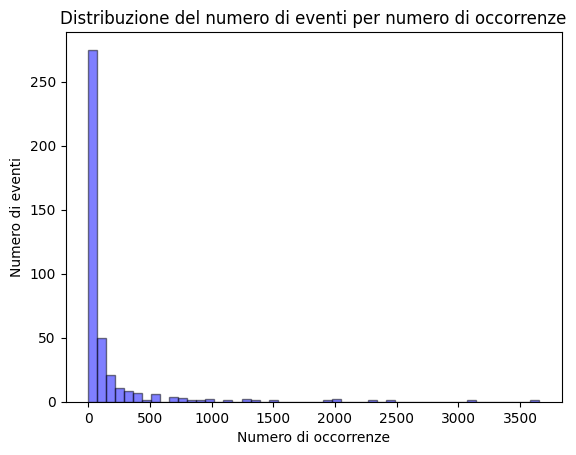

In [23]:
event_occurrences = dataset.groupby('Descrizione').count().sort_values('Flotta')['Flotta'].values

plt.hist(event_occurrences, bins=50, alpha=0.5, color='blue', edgecolor='black')
plt.title('Distribuzione del numero di eventi per numero di occorrenze')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Numero di eventi')
plt.show()


#### some other plots:

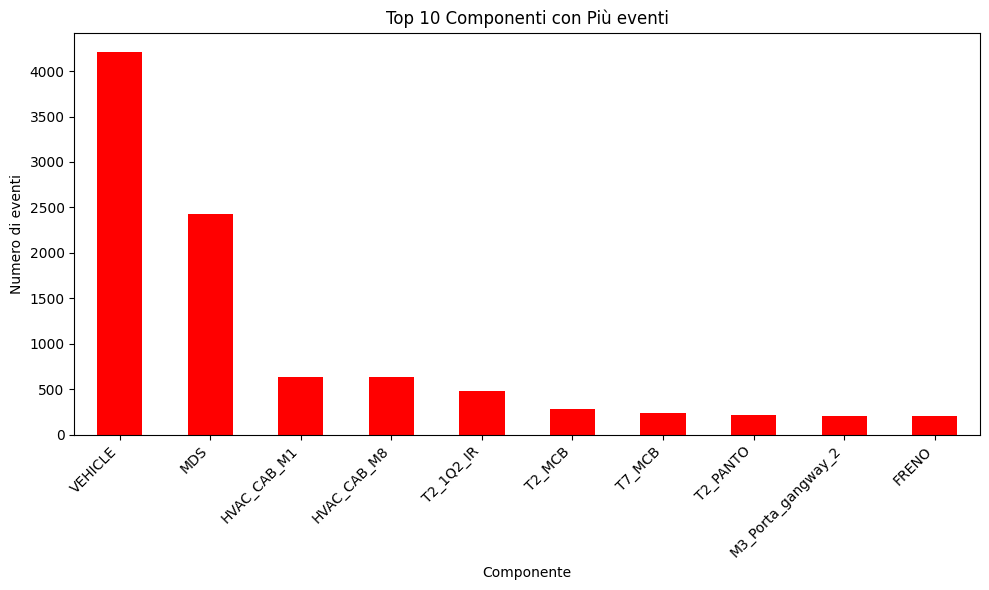

In [8]:
# popular "componente"
eventi_per_sistema = dataset_new.groupby(['Componente']).count()['Flotta']

top_events = eventi_per_sistema.nlargest(10)
plt.figure(figsize=(10, 6))
top_events.plot(kind='bar', color='red')
plt.title('Top 10 Componenti con Più eventi')
plt.xlabel('Componente')
plt.ylabel('Numero di eventi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



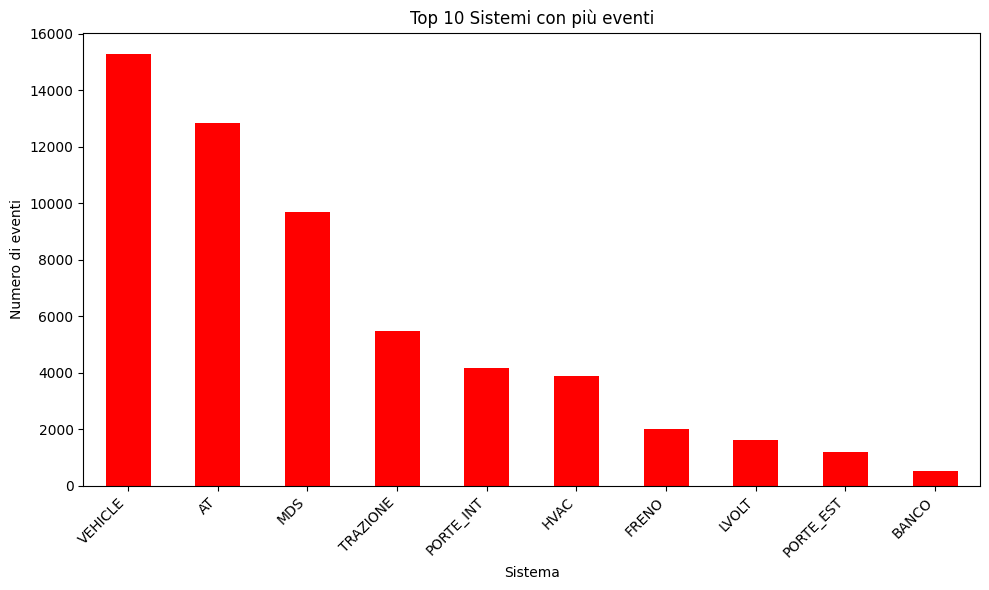

In [9]:
# popular "sistema"
eventi_per_sistema = dataset.groupby(['Sistema']).count()['Flotta']

top_events = eventi_per_sistema.nlargest(10)
plt.figure(figsize=(10, 6))
top_events.plot(kind='bar', color='red')
plt.title('Top 10 Sistemi con più eventi')
plt.xlabel('Sistema')
plt.ylabel('Numero di eventi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### filtering

==================== Teniamo soltanto i 5 componenti e sistemi più popolari ====================
Numero di righe prima del filtraggio: 57652
Numero di colonne prima della rimozione di colonne vuote: 169
Numero di righe dopo il filtraggio: 7998
Numero di colonne dopo la rimozione di colonne vuote: 56
==================== STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI (a valle dei filtraggi) ====================
count      63.000000
mean      126.952381
std       288.294452
min         1.000000
25%        18.000000
50%        39.000000
75%       101.500000
max      1486.000000
Name: Flotta, dtype: float64


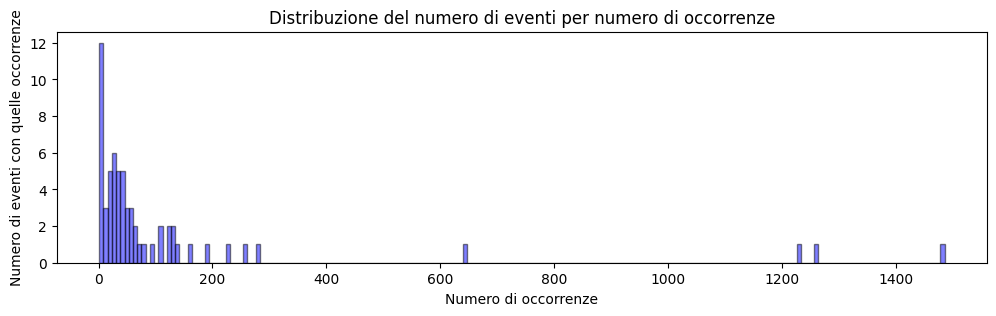

==================== PROPOSTA ====================
più raro è l'evento, più si può considerare essere un'anomalia.
Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un'anomalia???.
IL 25% degli eventi succede massimo 18.0  volte!
IL 50% degli eventi succede massimo 39.0  volte!
L 75% degli eventi succede massimo 101.5  volte!
Togliamo gli eventi il cui numero di occorrenze è una "coda" della distribuzione:
toglieremno  16   con molte occorrenze.
siamo rimasti con 63-16=47 eventi
==================== STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI (DOPO ULTERIORI filtraggi) ====================
count    47.000000
mean     29.659574
std      23.083286
min       1.000000
25%       8.500000
50%      29.000000
75%      42.000000
max      94.000000
Name: Flotta, dtype: float64


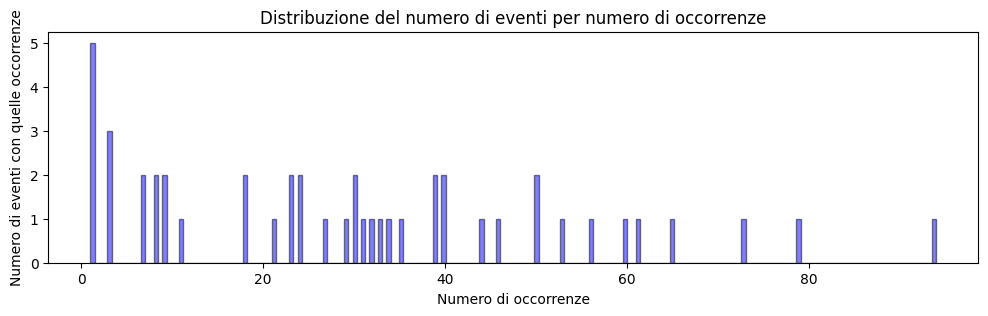

==================== PROPOSTA ====================
più raro è l'evento, più si può considerare essere un'anomalia.
Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un'anomalia???.
IL 25% degli eventi succede massimo 8.5  volte!
IL 50% degli eventi succede massimo 29.0  volte!
L 75% degli eventi succede massimo 42.0  volte!
Consideriamo anomalia tutto ciò che succede massimo 23.0 volte, corrispondete al quantile 0.4!
==================== Così facendo abbiamo: ====================
nel nostro dataset abbiamo 47 TIPI DI EVENTI diversi
sparsi in un totale di 1394 record
di cui 176 corrispondono ad anomalie


In [13]:
dataset = pd.read_csv('dataset.csv')
dataset_new = dataset.copy()
dataset_new['Timestamp'] = pd.to_datetime(dataset_new['Timestamp'], errors='coerce')
# timestamp will be essential
dataset_new = dataset_new.dropna(subset=['Timestamp'])
# repeated signals:
dataset_new = dataset_new.drop_duplicates(subset=['Descrizione', 'Timestamp'])

largest = 5 
anomalous_quantile = 0.4

print('='*20, f'Teniamo soltanto i {largest} componenti e sistemi più popolari','='*20)

top_components = list(dataset_new.groupby(['Componente']).count()['Flotta'].nlargest(largest).index)
top_sistems = list(dataset_new.groupby(['Sistema']).count()['Flotta'].nlargest(largest).index)

print(f"Numero di righe prima del filtraggio: {dataset.shape[0]}")
print(f"Numero di colonne prima della rimozione di colonne vuote: {dataset.shape[1]}")

dataset_new = dataset_new[dataset_new['Componente'].isin(top_components)]
dataset_new = dataset_new[dataset_new['Sistema'].isin(top_sistems)]

dataset_new = dataset_new.dropna(axis=1, how='all')
dataset_new = dataset_new.dropna()
dataset_new.set_index('Timestamp', inplace=True)
print(f"Numero di righe dopo il filtraggio: {dataset_new.shape[0]}")
print(f"Numero di colonne dopo la rimozione di colonne vuote: {dataset_new.shape[1]}")

events_and_occurrences = dataset_new.groupby('Descrizione').count()['Flotta']
print('='*20, 'STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI (a valle dei filtraggi)','='*20)
print(events_and_occurrences.describe())
event_occurrences = dataset_new.groupby('Descrizione').count().sort_values('Flotta')['Flotta']
plt.figure(figsize=(12, 3))
plt.hist(event_occurrences.values, bins=200, alpha=0.5, color='blue', edgecolor='black')
plt.title('Distribuzione del numero di eventi per numero di occorrenze')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Numero di eventi con quelle occorrenze')
plt.show()

print('='*20, 'PROPOSTA','='*20)
print('più raro è l\'evento, più si può considerare essere un\'anomalia.')
print('Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un\'anomalia???.')
print('IL 25% degli eventi succede massimo', events_and_occurrences.quantile(.25), ' volte!')
print('IL 50% degli eventi succede massimo', events_and_occurrences.quantile(.50), ' volte!')
print('L 75% degli eventi succede massimo', events_and_occurrences.quantile(.75), ' volte!')

print('Togliamo gli eventi il cui numero di occorrenze è una "coda" della distribuzione:')
all_events = set(dataset_new['Descrizione'].unique())
third_quantile_events = set(event_occurrences[event_occurrences <= events_and_occurrences.quantile(.75)].index)
upper_tail_events = all_events - third_quantile_events
events_to_remove = list(upper_tail_events)
events_to_keep = all_events - set(events_to_remove)
print('toglieremno ',len(upper_tail_events),"  con molte occorrenze.")

dataset_new = dataset_new[dataset_new['Descrizione'].isin(events_to_keep)]
eventi_totali = dataset_new['Descrizione'].nunique()
print(f"siamo rimasti con {len(all_events)}-{len(events_to_remove)}={eventi_totali} eventi")


events_and_occurrences = dataset_new.groupby('Descrizione').count()['Flotta']
print('='*20, 'STATISTICHE DI NUMERO DI OCCORRENZE DI EVENTI (DOPO ULTERIORI filtraggi)','='*20)
print(events_and_occurrences.describe())
event_occurrences = dataset_new.groupby('Descrizione').count().sort_values('Flotta')['Flotta']
plt.figure(figsize=(12, 3))
plt.hist(event_occurrences.values, bins=200, alpha=0.5, color='blue', edgecolor='black')
plt.title('Distribuzione del numero di eventi per numero di occorrenze')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Numero di eventi con quelle occorrenze')
plt.show()

print('='*20, 'PROPOSTA','='*20)
print('più raro è l\'evento, più si può considerare essere un\'anomalia.')
print('Quale è il valore minimo di occorrenze di un evento tale per cui esso NON è un\'anomalia???.')
print('IL 25% degli eventi succede massimo', events_and_occurrences.quantile(.25), ' volte!')
print('IL 50% degli eventi succede massimo', events_and_occurrences.quantile(.50), ' volte!')
print('L 75% degli eventi succede massimo', events_and_occurrences.quantile(.75), ' volte!')


min_occorrences_for_beign_normal = events_and_occurrences.quantile(anomalous_quantile)
print(f'Consideriamo anomalia tutto ciò che succede massimo {min_occorrences_for_beign_normal} volte, corrispondete al quantile {anomalous_quantile}!')

print('='*20, 'Così facendo abbiamo:','='*20)


print(f'nel nostro dataset abbiamo {eventi_totali} TIPI DI EVENTI diversi')
record_totali = len(dataset_new)
print(f'sparsi in un totale di {record_totali} record')

anomalies = event_occurrences[event_occurrences <= min_occorrences_for_beign_normal].index


record_anomalie = len(dataset_new[dataset_new['Descrizione'].isin(anomalies)])
print(f'di cui {record_anomalie} corrispondono ad anomalie')

### some other observations:

In [14]:
dataset_new[non_numeric_cols].nunique()

Descrizione             47
Timestamp chiusura    1156
Posizione               19
Flotta                   1
Veicolo                  1
Codice                  57
Nome                    48
Test                     1
Sistema                  4
Componente               5
Timestamp segnale      710
dtype: int64

In [15]:
dataset_new.groupby(['Codice','Nome','Descrizione'])['Flotta'].count()

Codice           Nome                  Descrizione                                                   
011200           CCU_FltWtbR1          Mancata ricezione R1 in CCU M1                                    29
011201           CCU_FltWtbR2          Mancata ricezione R2 in CCU M1                                    32
011202           CCU_FltWtbComm        Mancata comunicazione WTB in CCU M1                               61
011203           CCU_GtwFlt            Guasto GTW semitreno M1-T4                                         1
018200           CCU_FltWtbR1          Mancata ricezione R1 in CCU M8                                    23
018201           CCU_FltWtbR2          Mancata ricezione R2 in CCU M8                                    34
018202           CCU_FltWtbComm        Mancata comunicazione WTB in CCU M8                               56
020006           _NokVoltSts_          Incoerenza Tensione di Linea                                       1
081171           _CabDamperY5S2nto

In [16]:
dataset_new.groupby(['Posizione'])['Flotta'].count()

Posizione
Brescia                    21
Lonato del Garda            3
Milano                    486
Padova                      4
Palazzolo dello Stella      7
Peschiera del Garda         6
Portogruaro                 1
Ronchi dei Legionari        3
Rovato                     85
Sommacampagna               1
Sona                        2
Torviscosa                  1
Treviglio                  91
Trieste                    65
Truccazzano                 2
Venezia                   606
Verona                      5
Vicenza                     3
Vimodrone                   2
Name: Flotta, dtype: int64

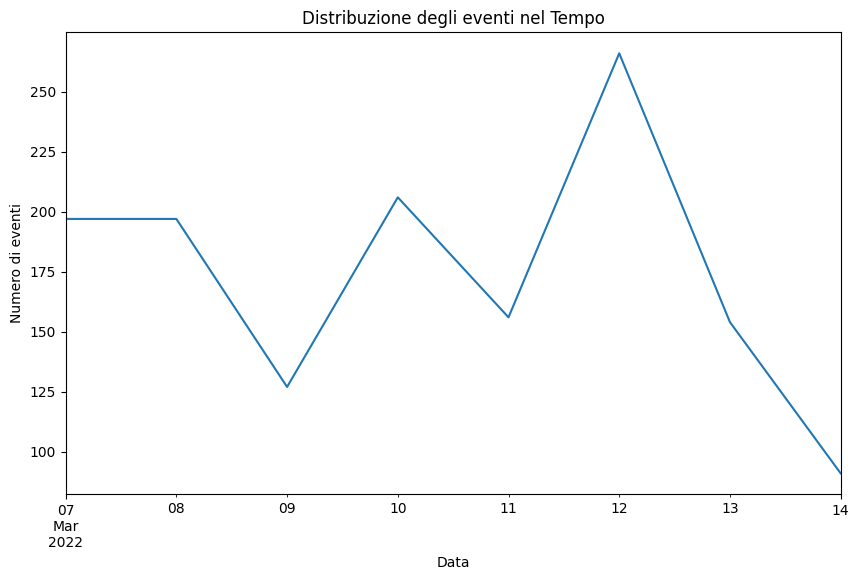

In [17]:
#visualizzazione della distribazione degli eventi nel tempo
dataset_new.resample('D').size().plot(title='Distribuzione degli eventi nel Tempo', figsize=(10, 6))
plt.xlabel('Data')
plt.ylabel('Numero di eventi')
plt.show()

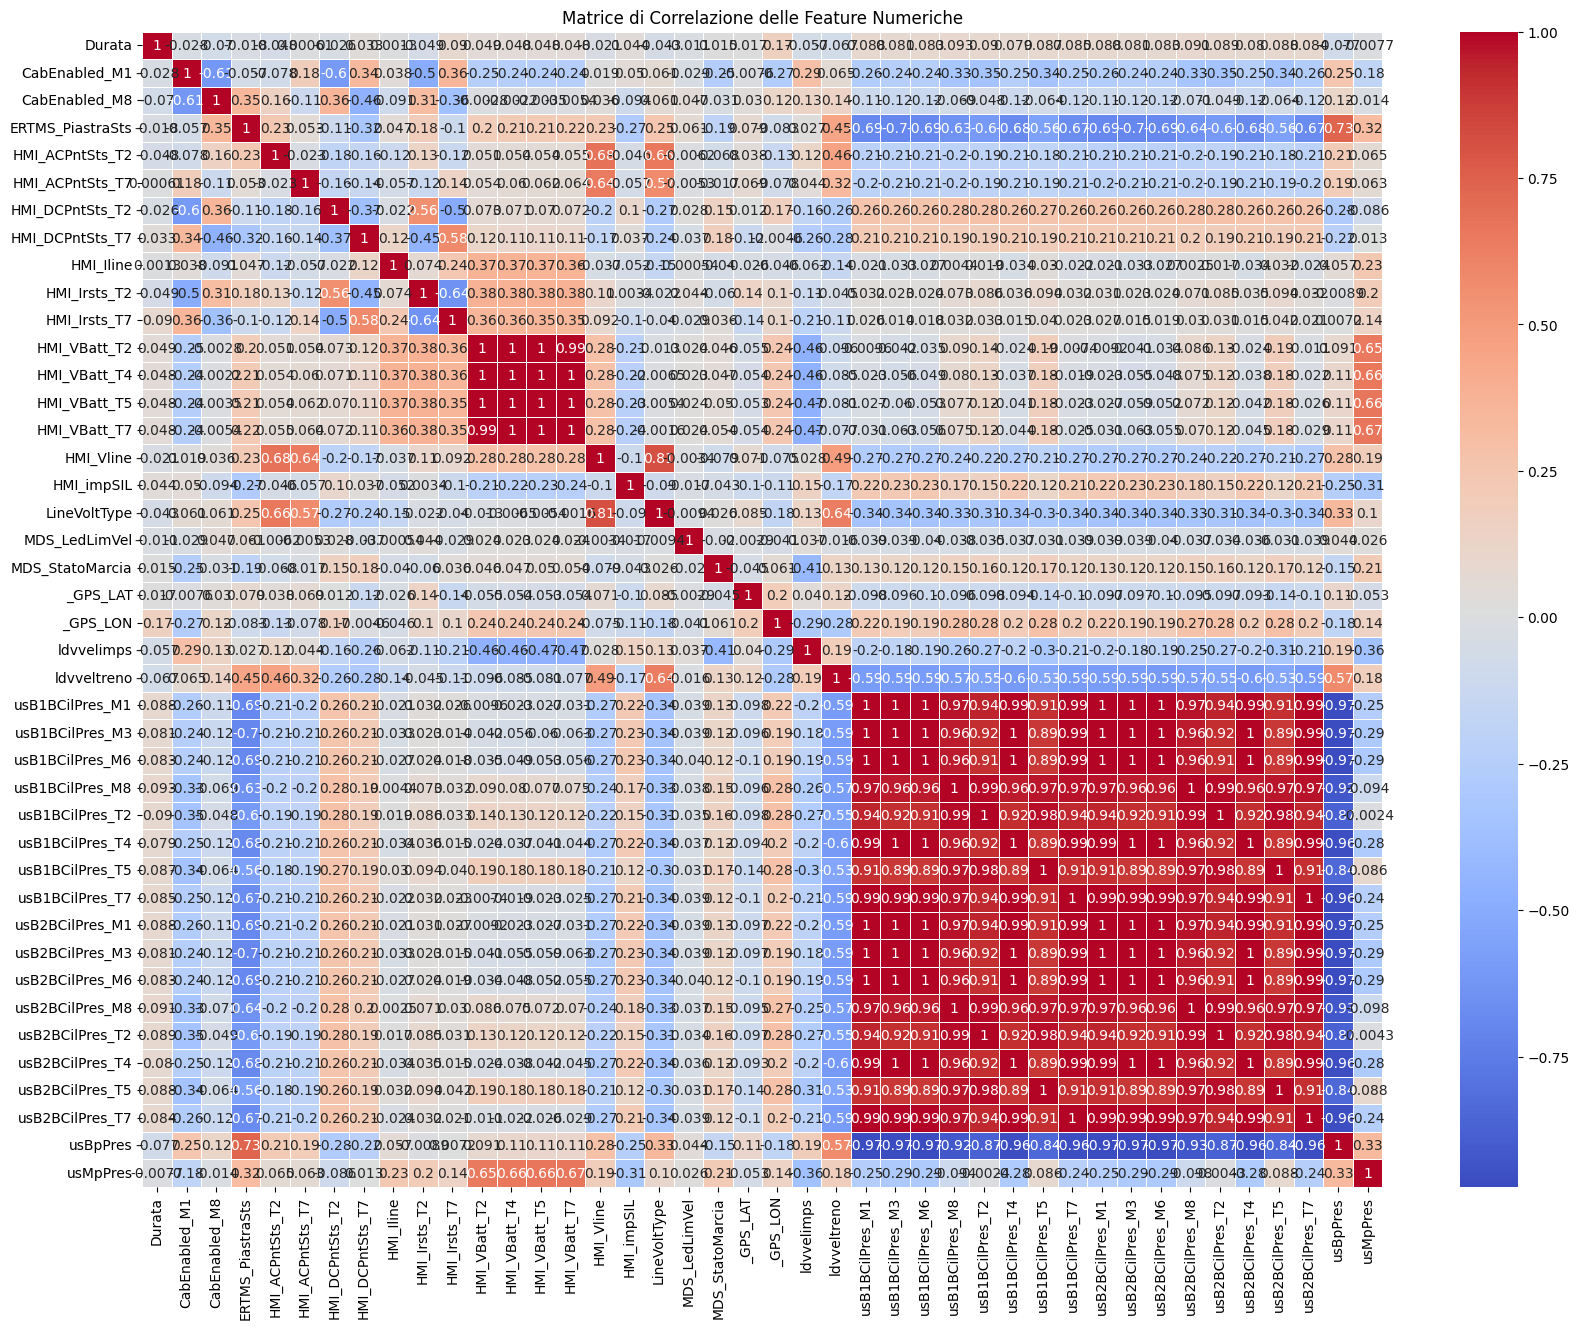

In [18]:
#matrice di correlazione
correlation_matrix = dataset_new[columns_to_generate].corr()
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice di Correlazione delle Feature Numeriche')
plt.show()

## Looking for statistical correlations 
______________________

Premise: 
- we are not taking into account the time-series nature of data, just tabular stuff.
- between numerical (i.e. from sensors) and non-numerical (i.e. from labels) data.
- "correlation" is intended ALSO in the non-linear setting. (we use UMAP)

Let's create a non linear 2D reduction of the numerical data at hand:

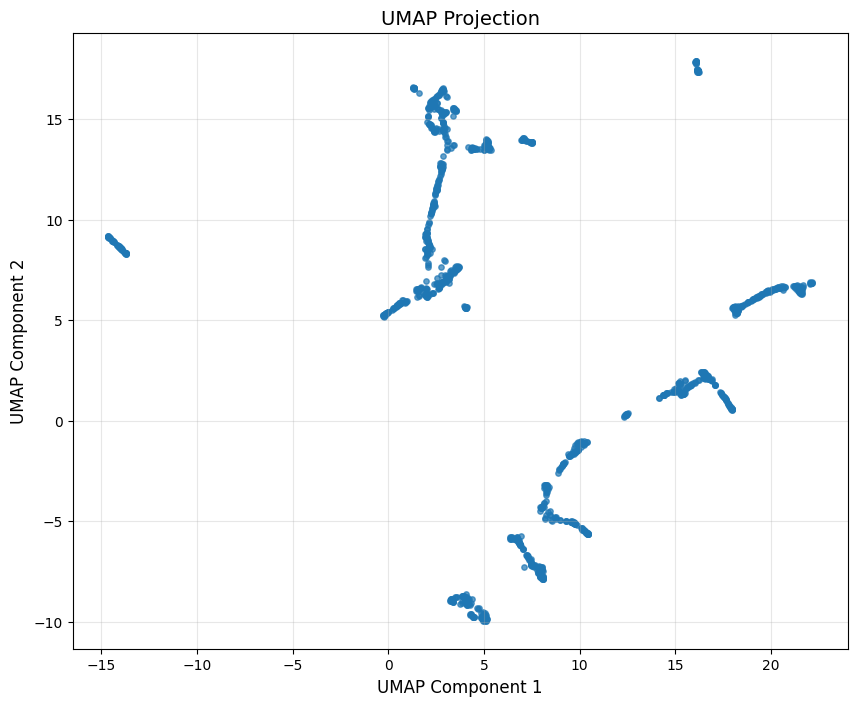

In [ ]:
X = dataset_new[columns_to_generate].values
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
# Fit and transform the data
embedding = reducer.fit_transform(X.reshape(X.shape[0], -1))

plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], s=15, alpha=0.7)
plt.title('UMAP Projection', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder


class MLP(nn.Module):
    def __init__(self, **kwargs):
        super(MLP, self).__init__()
        input_dim = kwargs.get('input_dim', 40)
        h_dim = kwargs.get('h_dim', 128)
        dropout = kwargs.get('dropout', 0.1)
        num_layers = kwargs.get('num_layers', 3)
        layer_norm = kwargs.get('layer_norm', False)
        output_dim = kwargs.get('output_dim',1)
        self.mode = kwargs.get('mode')
        
        main_stream = []

        if layer_norm:
            main_stream.append(nn.LayerNorm(input_dim))
        
        curr_output_dim = h_dim
        curr_main_input_dim = input_dim

        for _ in range(num_layers):
            main_stream.append(nn.Linear(curr_main_input_dim, curr_output_dim))
            main_stream.append(nn.ReLU())
            main_stream.append(nn.Dropout(dropout))
            curr_main_input_dim = curr_output_dim
            curr_output_dim = curr_output_dim // 2

        # manifold layer:
        curr_output_dim = 2
        self.manifold_layer = nn.Linear(curr_main_input_dim, curr_output_dim)
        curr_main_input_dim = curr_output_dim


        self.output_module = nn.Sequential(
            nn.Linear(curr_main_input_dim, output_dim),
            (nn.Sigmoid() if output_dim == 1 else nn.Softmax(1)))
        
        self.main_stream = nn.Sequential(*main_stream)
        print("Architecture of the MLP: ")
        print(self.parameters)
            
    def forward(self, x):
        
        main = self.main_stream(x)
        manifold = self.manifold_layer(main)
        return self.output_module(manifold), manifold.detach()


### Events:


==========Eventi più popolari:==========
Descrizione
Cod. 11 Rilascio Porte Destre Attivo         94
Stato RUNNING attivo                         79
Stato STANDBY attivo                         73
Cod. 10 Nessuna velocita' impostata          65
Mancata comunicazione WTB in CCU M1          61
Cod. 21 AT non presente                      60
Mancata comunicazione WTB in CCU M8          56
Cod. 15 Nessun banco abilitato               53
Cod. 02 Taglio trazione comandato da RCEC    50
Nessun IR o IP chiuso                        50
Name: Flotta, dtype: int64


Il dataset con i 10 eventi più gettonati è lungo  641 record
{'Cod. 11 Rilascio Porte Destre Attivo': 0, 'Stato RUNNING attivo': 1, 'Stato STANDBY attivo': 2, "Cod. 10 Nessuna velocita' impostata": 3, 'Mancata comunicazione WTB in CCU M1': 4, 'Cod. 21 AT non presente': 5, 'Mancata comunicazione WTB in CCU M8': 6, 'Cod. 15 Nessun banco abilitato': 7, 'Cod. 02 Taglio trazione comandato da RCEC': 8, 'Nessun IR o IP chiuso': 9}


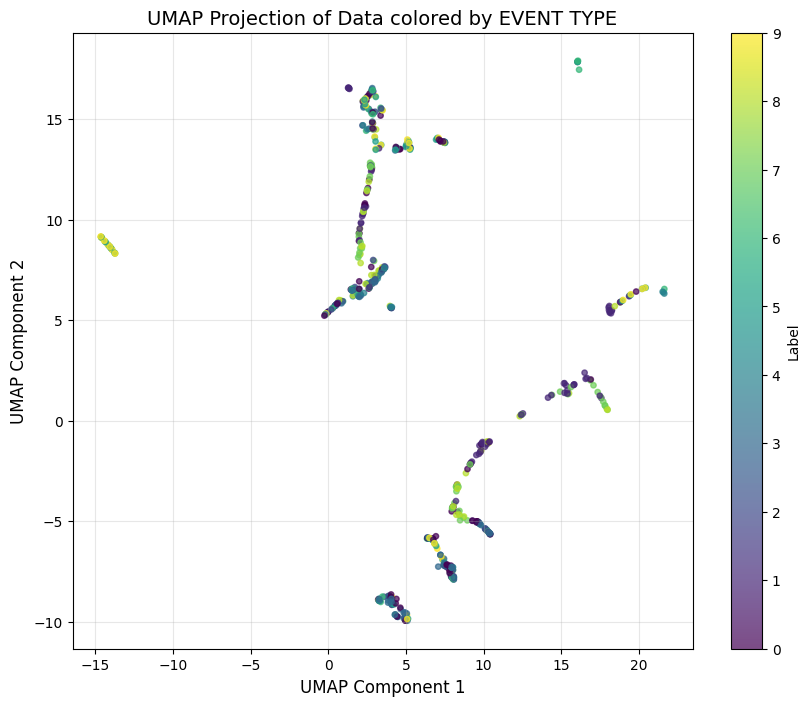

In [105]:
print("==========Eventi più popolari:==========")
print(dataset_new.groupby('Descrizione').count()['Flotta'].nlargest(10))
popular_descriptions = dataset_new.groupby('Descrizione')['Flotta'].count().nlargest(10).index
popular_events_ds = dataset_new[dataset_new['Descrizione'].isin(popular_descriptions)]
print("\n\n","="*50)
print('Il dataset con i 10 eventi più gettonati è lungo ',len(popular_events_ds), 'record')
print("="*50)
description_map = {desc: i for i, desc in enumerate(popular_descriptions)}
descrizioni_numeriche = popular_events_ds['Descrizione'].map(description_map)
print(description_map)

event_embedding = embedding[dataset_new['Descrizione'].isin(popular_descriptions)]
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(event_embedding[:, 0], event_embedding[:, 1], c=descrizioni_numeriche, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by EVENT TYPE', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()


### There is ALMOST NONE correlation between numerical features and POSITION:




==========Posizioni più popolari:==========
Posizione
Venezia                   606
Milano                    486
Treviglio                  91
Rovato                     85
Trieste                    65
Brescia                    21
Palazzolo dello Stella      7
Peschiera del Garda         6
Verona                      5
Padova                      4
Name: Flotta, dtype: int64
il dataset con i 10 eventi più gettonati è le 10 posizioni più gettonate e lungo  1394 record
{'Venezia': 0, 'Milano': 1, 'Treviglio': 2, 'Rovato': 3, 'Trieste': 4, 'Brescia': 5, 'Palazzolo dello Stella': 6, 'Peschiera del Garda': 7, 'Verona': 8, 'Padova': 9}


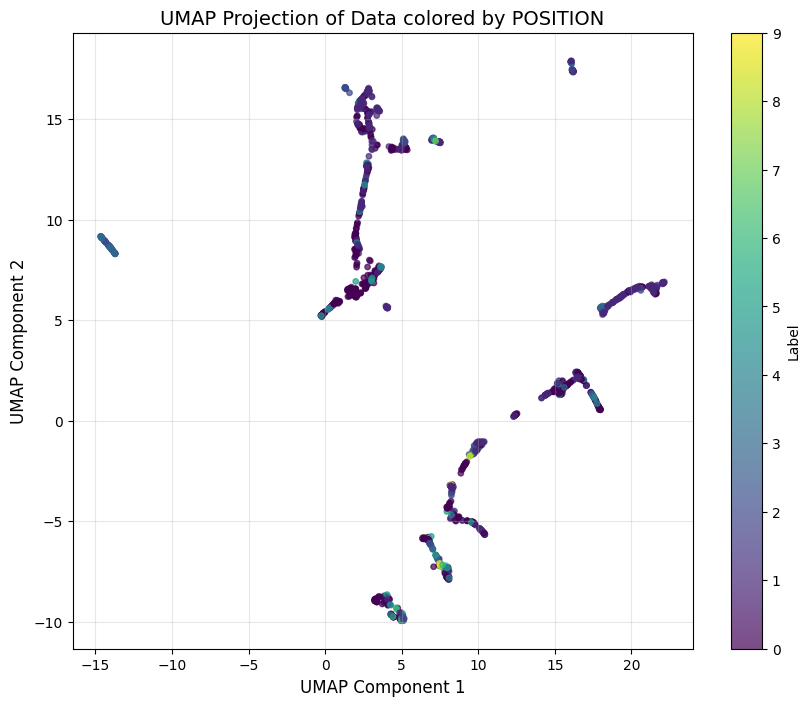

In [106]:
print("\n\n\n==========Posizioni più popolari:==========")
print(dataset_new.groupby('Posizione')['Flotta'].count().nlargest(10))
popular_positions = dataset_new.groupby('Posizione')['Flotta'].count().nlargest(10).index
popular_positions_ds = dataset_new[dataset_new['Posizione'].isin(popular_positions)]
print("="*50)
print('il dataset con i 10 eventi più gettonati è le 10 posizioni più gettonate e lungo ',len(dataset_new), 'record')
print("="*50)
position_map = {desc: i for i, desc in enumerate(popular_positions)}
posizioni_numeriche = popular_positions_ds['Posizione'].map(position_map)
positions_embedding = embedding[dataset_new['Posizione'].isin(popular_positions)]
print(position_map)
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(positions_embedding[:, 0], positions_embedding[:, 1], c=posizioni_numeriche, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by POSITION', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

### Anomalies

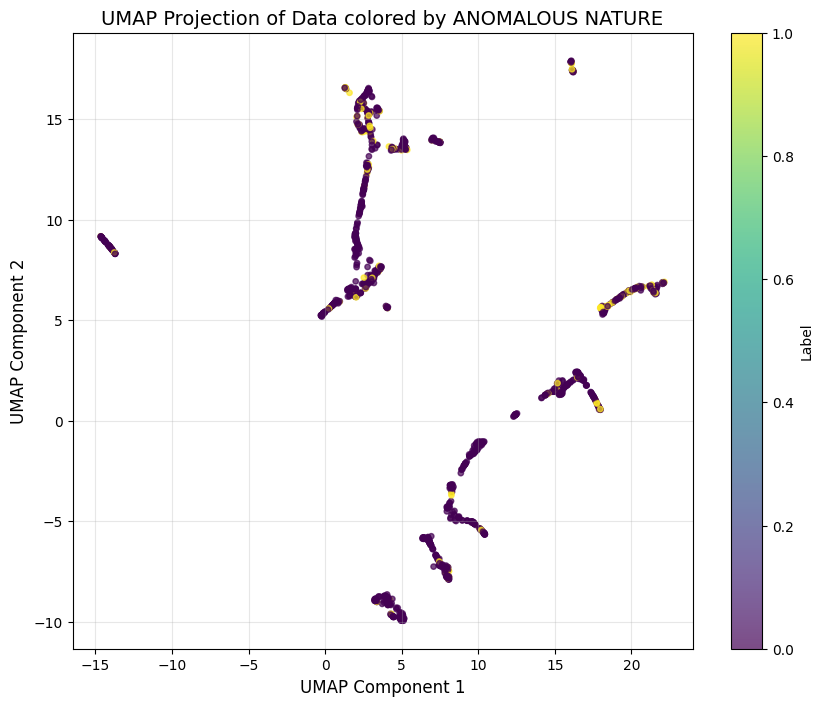

In [24]:
anomalous = dataset_new['Descrizione'].isin(anomalies).values
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=anomalous, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by ANOMALOUS NATURE', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

Architecture of the MLP: 
<bound method Module.parameters of MLP(
  (manifold_layer): Linear(in_features=32, out_features=2, bias=True)
  (output_module): Sequential(
    (0): Linear(in_features=2, out_features=2, bias=True)
    (1): Sigmoid()
  )
  (main_stream): Sequential(
    (0): LayerNorm((42,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=42, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=64, out_features=32, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.1, inplace=False)
  )
)>
Epoch 1, Test Accuracy: 0.8674
Epoch 2, Test Accuracy: 0.8674
Epoch 3, Test Accuracy: 0.8674
Epoch 4, Test Accuracy: 0.8674
Epoch 5, Test Accuracy: 0.8674
Epoch 6, Test Accuracy: 0.8674
Epoch 7, Test Accuracy: 0.8674
Epoch 8, Test Accuracy: 0.8674
Epoch 9, Test Accuracy: 0.8674
Epoch 10, Test Accuracy: 0.8

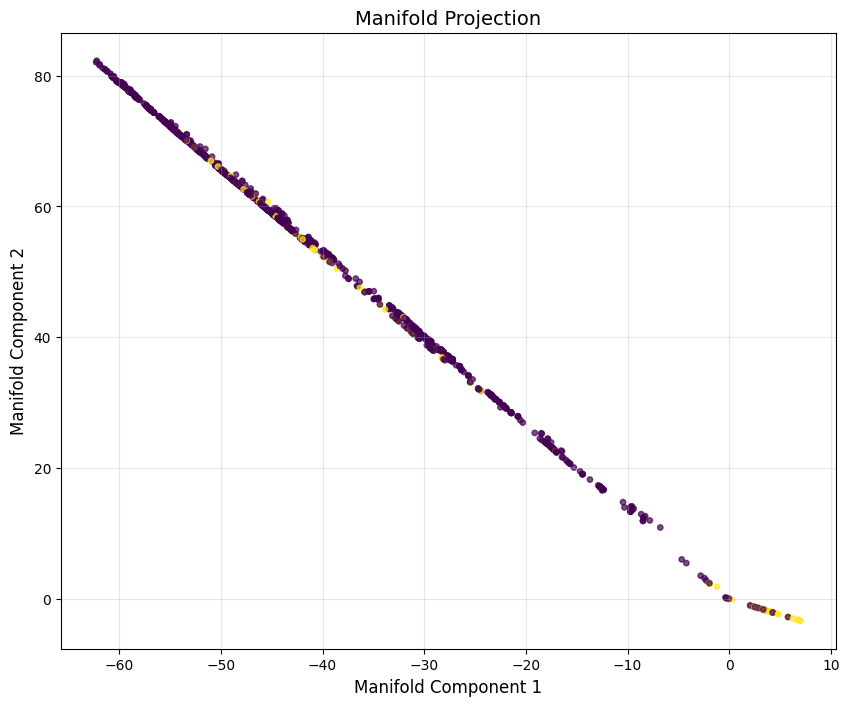

In [104]:
classifier = MLP(
    **{
        'input_dim': X.shape[1],
        'output_dim': 2,
        'layer_norm': True,
        'mode':'OF'})


Y = anomalous = dataset_new['Descrizione'].isin(anomalies).values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).long())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).long())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

for epoch in range(50):
    classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = classifier(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = classifier(x)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')


all_X_scaled = train_scaler.transform(X)
all_X_scaled = torch.Tensor(all_X_scaled).float()
classifier.eval()
all_preds, manifold = classifier(all_X_scaled)
all_preds = (torch.sigmoid(output.squeeze()) > 0.5).long()
manifold = manifold.numpy()

plt.figure(figsize=(10, 8))
plt.scatter(manifold[:, 0], manifold[:, 1], c=Y.astype(int), s=15, alpha=0.7)
plt.title('Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()



### System:

Sistema
AT          113
HVAC         13
MDS         215
VEHICLE    1053
Name: Flotta, dtype: int64
{'VEHICLE': 0, 'MDS': 1, 'AT': 2, 'HVAC': 3}


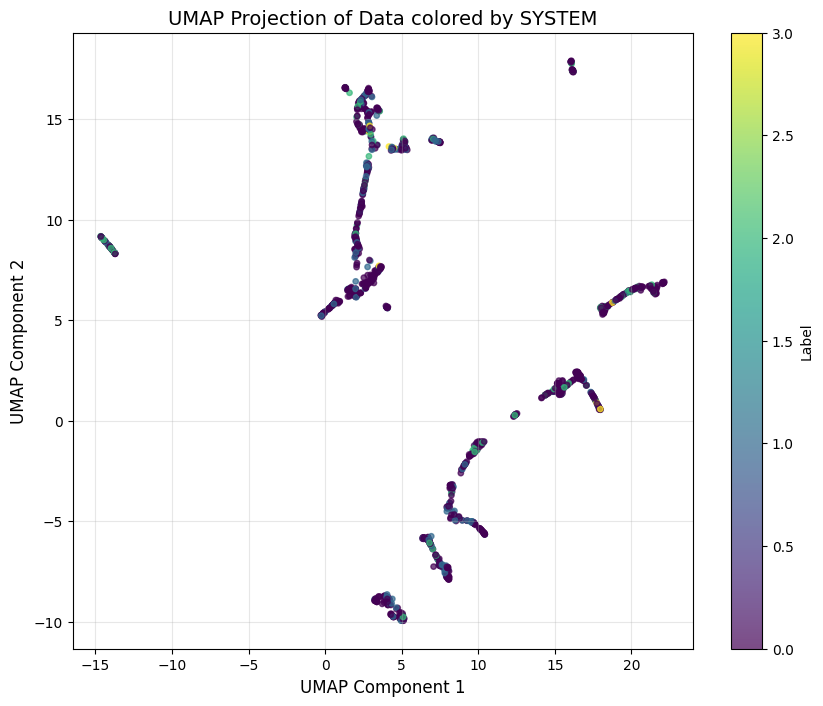

In [108]:
print(dataset_new.groupby('Sistema')['Flotta'].count())
systems = list(dataset_new['Sistema'].unique())
system_map = {desc: i for i, desc in enumerate(systems)}
sistemi_numerici = dataset_new['Sistema'].map(system_map)
print(system_map)
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=sistemi_numerici, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by SYSTEM', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

Architecture of the MLP: 
<bound method Module.parameters of MLP(
  (manifold_layer): Linear(in_features=32, out_features=2, bias=True)
  (output_module): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): Sigmoid()
  )
  (main_stream): Sequential(
    (0): LayerNorm((42,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=42, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=64, out_features=32, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.1, inplace=False)
  )
)>
Epoch 1, Test Accuracy: 0.7634
Epoch 2, Test Accuracy: 0.7634
Epoch 3, Test Accuracy: 0.7634
Epoch 4, Test Accuracy: 0.7634
Epoch 5, Test Accuracy: 0.7634
Epoch 6, Test Accuracy: 0.7634
Epoch 7, Test Accuracy: 0.7634
Epoch 8, Test Accuracy: 0.7634
Epoch 9, Test Accuracy: 0.7634
Epoch 10, Test Accuracy: 0.7

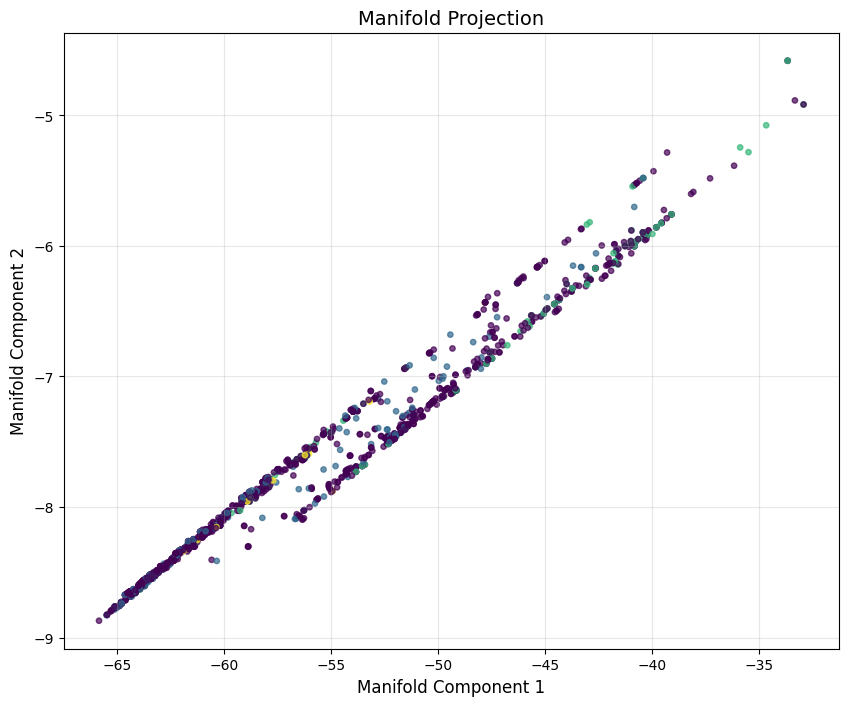

In [116]:
classifier = MLP(
    **{
        'input_dim': X.shape[1],
        'output_dim': 4,
        'layer_norm': True,
        'mode':'OF'})


Y  = sistemi_numerici.values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).long())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).long())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

for epoch in range(50):
    classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = classifier(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = classifier(x)
            predicted = torch.argmax(output, dim=1)
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')


all_X_scaled = train_scaler.transform(X)
all_X_scaled = torch.Tensor(all_X_scaled).float()
classifier.eval()
all_preds, manifold = classifier(all_X_scaled)
all_preds = (torch.sigmoid(output.squeeze()) > 0.5).long()
manifold = manifold.numpy()

plt.figure(figsize=(10, 8))
plt.scatter(manifold[:, 0], manifold[:, 1], c=Y.astype(int), s=15, alpha=0.7)
plt.title('Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()



### Component

{'VEHICLE': 0, 'MDS': 1, 'T2_1Q2_IR': 2, 'HVAC_CAB_M8': 3, 'HVAC_CAB_M1': 4}


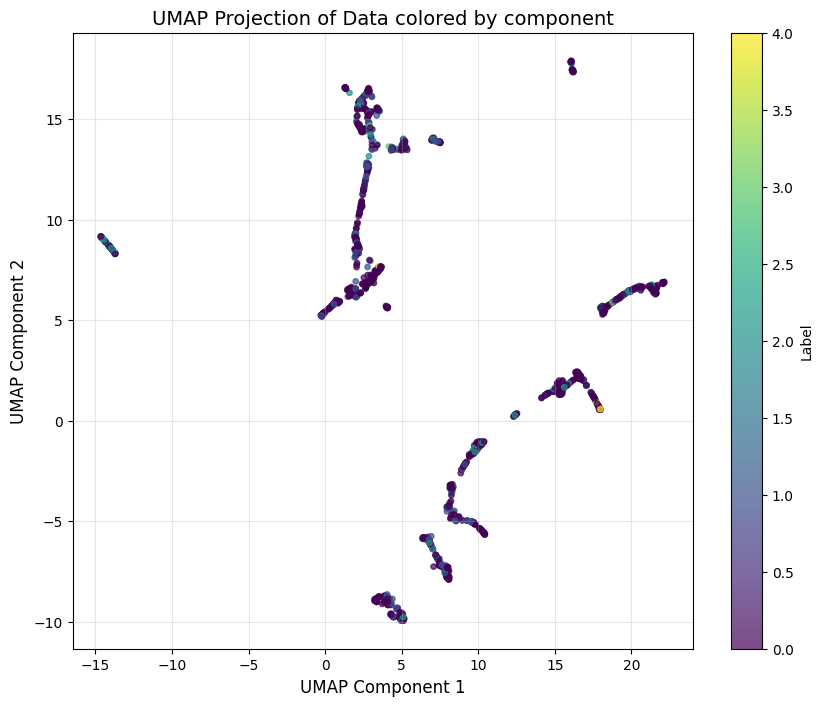

In [31]:
components = list(dataset_new['Componente'].unique())
component_map = {desc: i for i, desc in enumerate(components)}
sistemi_numerici = dataset_new['Componente'].map(component_map)
print(component_map)
# Visualize the UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=sistemi_numerici, s=15, alpha=0.7)
plt.title('UMAP Projection of Data colored by component', fontsize=14)
plt.xlabel('UMAP Component 1', fontsize=12)
plt.ylabel('UMAP Component 2', fontsize=12)
plt.colorbar(label='Label')
plt.grid(True, alpha=0.3)
plt.show()

### Overfitting:

Architecture of the MLP: 
<bound method Module.parameters of MLP(
  (manifold_layer): Linear(in_features=32, out_features=2, bias=True)
  (output_module): Sequential(
    (0): Linear(in_features=2, out_features=1, bias=True)
    (1): Sigmoid()
  )
  (main_stream): Sequential(
    (0): LayerNorm((42,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=42, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=64, out_features=32, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.1, inplace=False)
  )
)>
Epoch 1, Test Accuracy: 0.8674
Epoch 2, Test Accuracy: 0.8674
Epoch 3, Test Accuracy: 0.8674
Epoch 4, Test Accuracy: 0.8674
Epoch 5, Test Accuracy: 0.8674
Epoch 6, Test Accuracy: 0.8674
Epoch 7, Test Accuracy: 0.8674
Epoch 8, Test Accuracy: 0.8674
Epoch 9, Test Accuracy: 0.8674
Epoch 10, Test Accuracy: 0.8

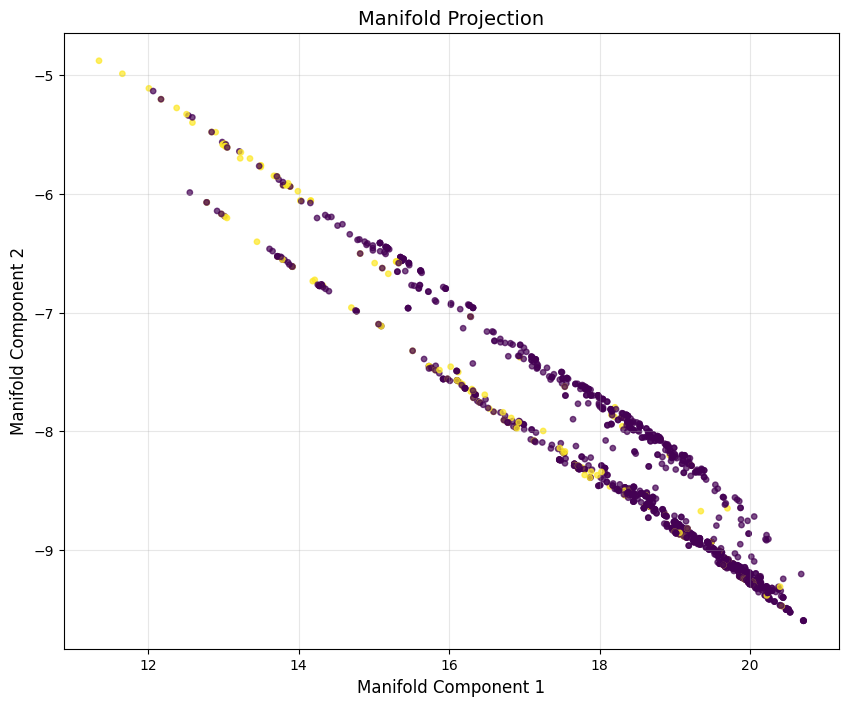

In [98]:
classifier = MLP(
    **{
        'input_dim': X.shape[1],
        'layer_norm': True,
        'mode':'OF'})

Y = anomalous = dataset_new['Descrizione'].isin(anomalies).values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

train_scaler = MinMaxScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_train_scaled).float(),
    torch.tensor(Y_train).float())
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_test_scaled).float(),
    torch.tensor(Y_test).float())

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False)

for epoch in range(50):
    classifier.train()
    for x, y in train_dataloader:
        optimizer.zero_grad()
        output, _ = classifier(x)
        loss = criterion(output.squeeze(), y)
        loss.backward()
        optimizer.step()

    classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for x, y in test_dataloader:
            output, _ = classifier(x)
            predicted = (output.squeeze() > 0.5).long()
            total_correct += (predicted == y).sum().item()
    accuracy = total_correct / len(test_dataset)
    print(f'Epoch {epoch+1}, Test Accuracy: {accuracy:.4f}')


all_X_scaled = train_scaler.transform(X)
all_X_scaled = torch.Tensor(all_X_scaled).float()
classifier.eval()
all_preds, manifold = classifier(all_X_scaled)
all_preds = (torch.sigmoid(output.squeeze()) > 0.5).long()
manifold = manifold.numpy()

plt.figure(figsize=(10, 8))
plt.scatter(manifold[:, 0], manifold[:, 1], c=Y.astype(int), s=15, alpha=0.7)
plt.title('Manifold Projection', fontsize=14)
plt.xlabel('Manifold Component 1', fontsize=12)
plt.ylabel('Manifold Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

